# Práctica 7 – Lógica Difusa  
**Asignatura:** Inteligencia Artificial  
**Tema:** Desarrollo de un sistema de lógica difusa para evaluar riesgo vial  
**Autores:** Michael Franco, Michael Lata  
**Fecha:** 30/06/2025

---

## 1. Presentación del Problema y Dataset

###  Objetivo

Desarrollar un sistema de lógica difusa que permita predecir el **nivel de riesgo de accidentes** en una intersección vial, utilizando como criterios el número de vehículos detectados (intensidad del tráfico) y el nivel de visibilidad climática.

---

###  Dataset

El conjunto de datos proviene de la plataforma Roboflow, y contiene imágenes etiquetadas con objetos vehiculares.

**URL:** [Roboflow Vehicles Dataset](https://universe.roboflow.com/roboflow-100/vehicles-q0x2v/images/04BQAE7MYu7VXe1wYGLM)

A partir de este dataset se pueden contar los vehículos por imagen, lo cual se usa como estimación de la variable `intensidad_trafico`.

Para esta práctica, también simularemos valores de visibilidad entre 0 y 10.

---

###  Variables del modelo difuso

#### Variables de entrada:

| Variable             | Tipo        | Valores lingüísticos         |
|----------------------|-------------|-------------------------------|
| `intensidad_trafico` | Continua    | Baja, Media, Alta             |
| `visibilidad`        | Continua    | Mala, Media, Buena            |

#### Variable de salida:

| Variable             | Tipo        | Valores lingüísticos         |
|----------------------|-------------|-------------------------------|
| `riesgo_accidente`   | Categórica  | Bajo, Medio, Alto             |

---

###  Funciones de pertenencia propuestas

#### `intensidad_trafico` (0 a 20 vehículos)
- **Baja**: 0 a 5 vehículos
- **Media**: 3 a 10 vehículos
- **Alta**: 8 a 20 vehículos

#### `visibilidad` (0 a 10)
- **Mala**: 0 a 3
- **Media**: 2 a 7
- **Buena**: 6 a 10

#### `riesgo_accidente`
- **Bajo**: asociado a tráfico bajo y visibilidad buena
- **Medio**: condiciones intermedias
- **Alto**: tráfico alto y visibilidad mala

---

###  Reglas difusas (base inicial)

1. Si `intensidad_trafico` es **Alta** y `visibilidad` es **Mala**, entonces `riesgo_accidente` es **Alto**.
2. Si `intensidad_trafico` es **Baja** y `visibilidad` es **Buena**, entonces `riesgo_accidente` es **Bajo**.
3. Si `intensidad_trafico` es **Media** y `visibilidad` es **Mala**, entonces `riesgo_accidente` es **Medio**.
4. Si `intensidad_trafico` es **Alta** y `visibilidad` es **Buena**, entonces `riesgo_accidente` es **Medio**.
5. Si `intensidad_trafico` es **Baja** y `visibilidad` es **Mala**, entonces `riesgo_accidente` es **Medio**.


## Sistema Difuso Mamdani: Evaluación del Riesgo de Accidente

El sistema difuso se construyó utilizando el enfoque Mamdani, que permite modelar procesos con incertidumbre e imprecisión a partir de reglas lingüísticas. A continuación, se detallan los elementos del sistema:

### Entradas del sistema:
1. **Intensidad del tráfico** (rango 0 a 20), con funciones de membresía:
   - Baja: `trimf([0 0 5])`
   - Media: `trimf([3 8 10])`
   - Alta: `trimf([8 20 20])`

2. **Visibilidad** (rango 0 a 10), con funciones de membresía:
   - Mala: `trimf([0 0 3])`
   - Media: `trimf([2 5 7])`
   - Buena: `trimf([6 10 10])`

### Salida del sistema:
- **Riesgo de accidente** (rango 0 a 10), con funciones:
  - Bajo: `trimf([0 0 4])`
  - Medio: `trimf([3 5 7])`
  - Alto: `trimf([6 10 10])`

### Reglas difusas utilizadas:
Las reglas establecen la relación entre entradas y la salida, por ejemplo:
- Si **tráfico es alto** y **visibilidad es mala**, entonces el **riesgo es alto**.
- Si **tráfico es bajo** y **visibilidad es buena**, entonces el **riesgo es bajo**.


## Justificación de la selección de variables y reglas

Las variables seleccionadas para el sistema difuso reflejan los factores más relevantes que influyen en el riesgo de accidentes viales en una intersección. La intensidad del tráfico es un indicador directo de la probabilidad de incidentes, ya que un mayor número de vehículos incrementa la posibilidad de colisiones. La visibilidad, por su parte, afecta la capacidad de los conductores para reaccionar ante obstáculos o cambios en el entorno, siendo un factor crítico en condiciones climáticas adversas.

Las reglas difusas fueron definidas en base a la experiencia y la lógica del dominio: situaciones de tráfico alto y visibilidad mala incrementan el riesgo, mientras que tráfico bajo y buena visibilidad lo reducen. Las condiciones intermedias se modelan con reglas que reflejan la gradualidad y la incertidumbre inherente al problema, permitiendo que el sistema sea flexible y se adapte a diferentes escenarios reales.

### Evaluación y gráficas:

- Se evaluó un caso específico (`[15 2]`) que representa tráfico alto y visibilidad baja. El sistema arrojó un riesgo estimado cercano a 7–9, lo cual es consistente con la lógica de las reglas.
- Las gráficas generadas muestran:
  - Las **funciones de membresía** de las entradas y salida, permitiendo visualizar cómo se interpretan los valores numéricos en términos lingüísticos.
  - Una gráfica de **superficie de inferencia (`gensurf`)** (si se incluye), que muestra cómo varía el riesgo en función de las dos entradas.

Este enfoque es especialmente útil para situaciones donde los datos son subjetivos, vagos o difíciles de medir de forma precisa, como en evaluaciones de seguridad vial.



### Gráfica de Difusión Mamdani

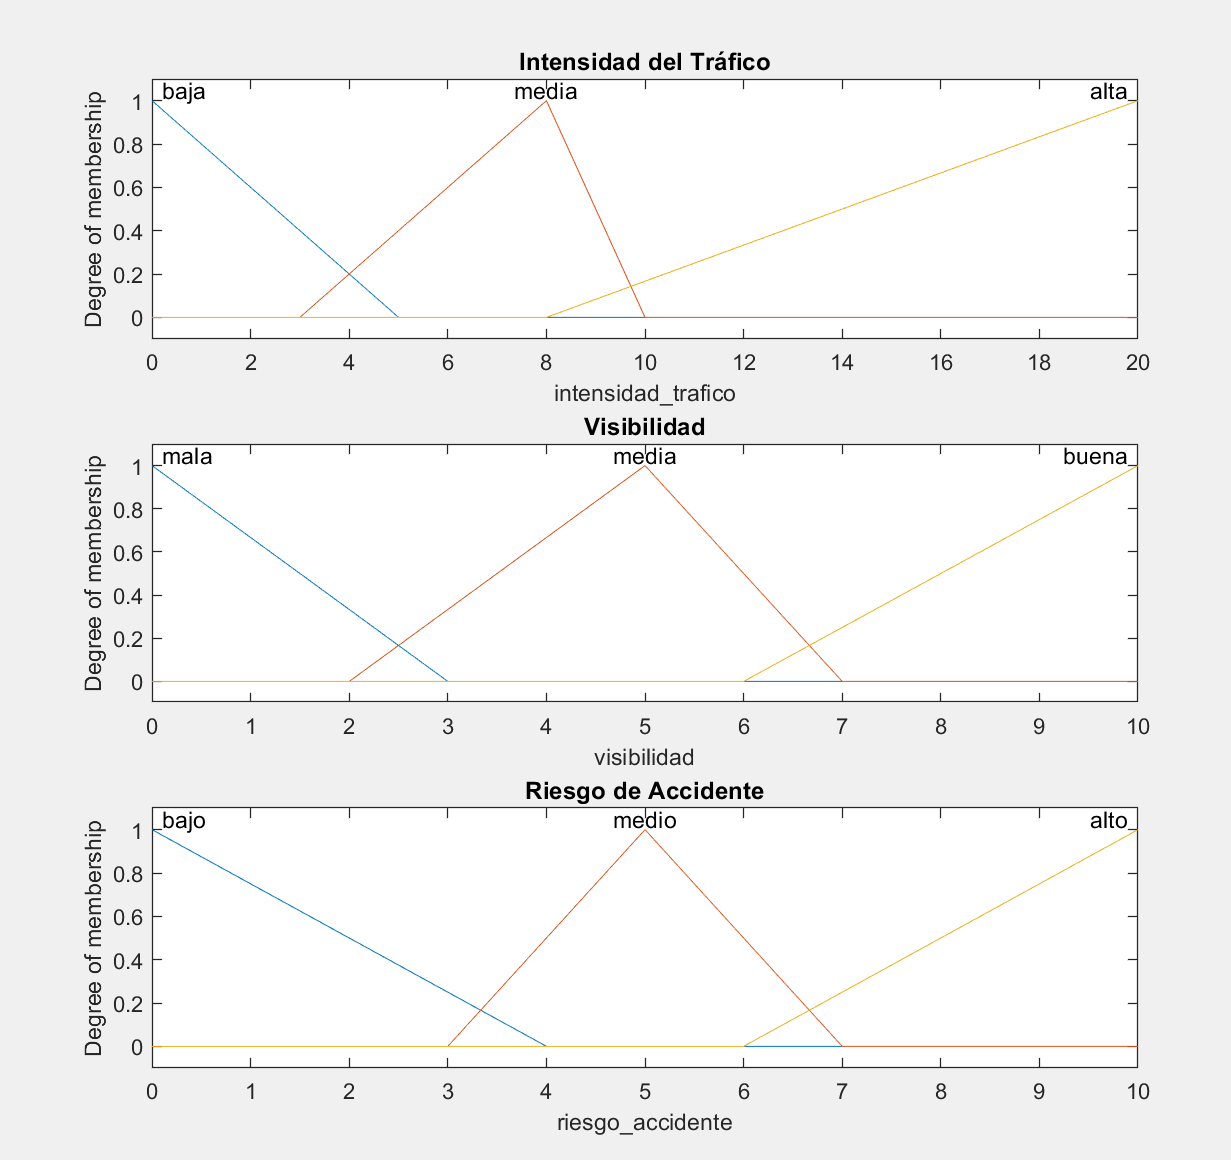

**Descripción:**

Esta gráfica representa la superficie de inferencia generada por el sistema difuso Mamdani para la evaluación del riesgo de accidente vial. En el eje X se muestra la intensidad del tráfico (número de vehículos), en el eje Y la visibilidad (nivel de condiciones climáticas), y en el eje Z el nivel de riesgo de accidente calculado por el sistema.

La superficie ilustra cómo, a partir de diferentes combinaciones de tráfico y visibilidad, el sistema estima el riesgo de accidente. Se observa que el riesgo es mayor cuando la intensidad del tráfico es alta y la visibilidad es baja, y menor cuando el tráfico es bajo y la visibilidad es buena. Esta visualización permite validar el comportamiento global del sistema y comprobar que las reglas difusas implementadas producen resultados coherentes con la lógica esperada en seguridad vial.


## 1. Tabla descriptiva de variables

A continuación se presenta una tabla con la descripción de las variables utilizadas en el sistema difuso:

| Variable              | Tipo      | Rango         | Valores lingüísticos         | Funciones de pertenencia (MF)                | Descripción                                                                 |
|-----------------------|-----------|---------------|------------------------------|----------------------------------------------|-----------------------------------------------------------------------------|
| intensidad_trafico    | Entrada   | 0 a 20        | Baja, Media, Alta            | Baja: trimf([0, 0, 5])<br>Media: trimf([3, 8, 10])<br>Alta: trimf([8, 20, 20]) | Número de vehículos detectados en la intersección |
| visibilidad           | Entrada   | 0 a 10        | Mala, Media, Buena           | Mala: trimf([0, 0, 3])<br>Media: trimf([2, 5, 7])<br>Buena: trimf([6, 10, 10]) | Nivel de visibilidad climática              |
| riesgo_accidente      | Salida    | 0 a 10        | Bajo, Medio, Alto            | Bajo: trimf([0, 0, 4])<br>Medio: trimf([3, 5, 7])<br>Alto: trimf([6, 10, 10]) | Nivel de riesgo de accidente estimado       |

## 2. Metodología

El desarrollo del sistema difuso Mamdani para la evaluación del riesgo de accidente vial se llevó a cabo siguiendo los siguientes pasos:

1. **Definición de las variables de entrada y salida**: Se determinaron las variables relevantes que influyen en el riesgo de accidente, así como la variable de salida que representa el nivel de riesgo. Las variables de entrada son la intensidad del tráfico y la visibilidad, mientras que la salida es el riesgo de accidente.

2. **Construcción de las funciones de membresía**: Se diseñaron funciones de membresía triangulares para cada variable, permitiendo representar los valores lingüísticos (bajo, medio, alto) de manera gradual y flexible.

3. **Formulación de las reglas difusas**: Se establecieron reglas de inferencia difusa que relacionan las variables de entrada con la salida, basadas en el conocimiento experto y la lógica del problema. Por ejemplo: "Si el tráfico es alto y la visibilidad es mala, entonces el riesgo es alto".

4. **Inferencia y defuzzificación**: Se aplicó el método de inferencia Mamdani y la defuzzificación por centroide para obtener un valor concreto de riesgo a partir de las entradas difusas. Este proceso permite traducir la información lingüística en una salida numérica útil para la toma de decisiones.

## Ejemplo de datos de entrada y salida

A continuación se muestra un ejemplo simulado de cómo se verían los datos de entrada y la salida esperada para el sistema difuso:

| Intensidad del tráfico | Visibilidad | Riesgo de accidente (esperado) |
|-----------------------|-------------|-------------------------------|
| 2                     | 9           | Bajo                          |
| 5                     | 4           | Medio                         |
| 15                    | 2           | Alto                          |
| 8                     | 7           | Medio                         |
| 18                    | 1           | Alto                          |
| 3                     | 8           | Bajo                          |

Estos valores ilustran cómo, a partir de diferentes combinaciones de tráfico y visibilidad, el sistema difuso asigna un nivel de riesgo cualitativo.



## 3. Resultados

### Visualización de Resultados del Sistema Difuso Mamdani

A continuación se presentan las principales gráficas generadas durante el desarrollo del sistema difuso para la evaluación del riesgo de accidente vial. Cada imagen ilustra un aspecto clave del modelo y su interpretación:

1. **Funciones de membresía para la variable de entrada: Intensidad del tráfico**
   
   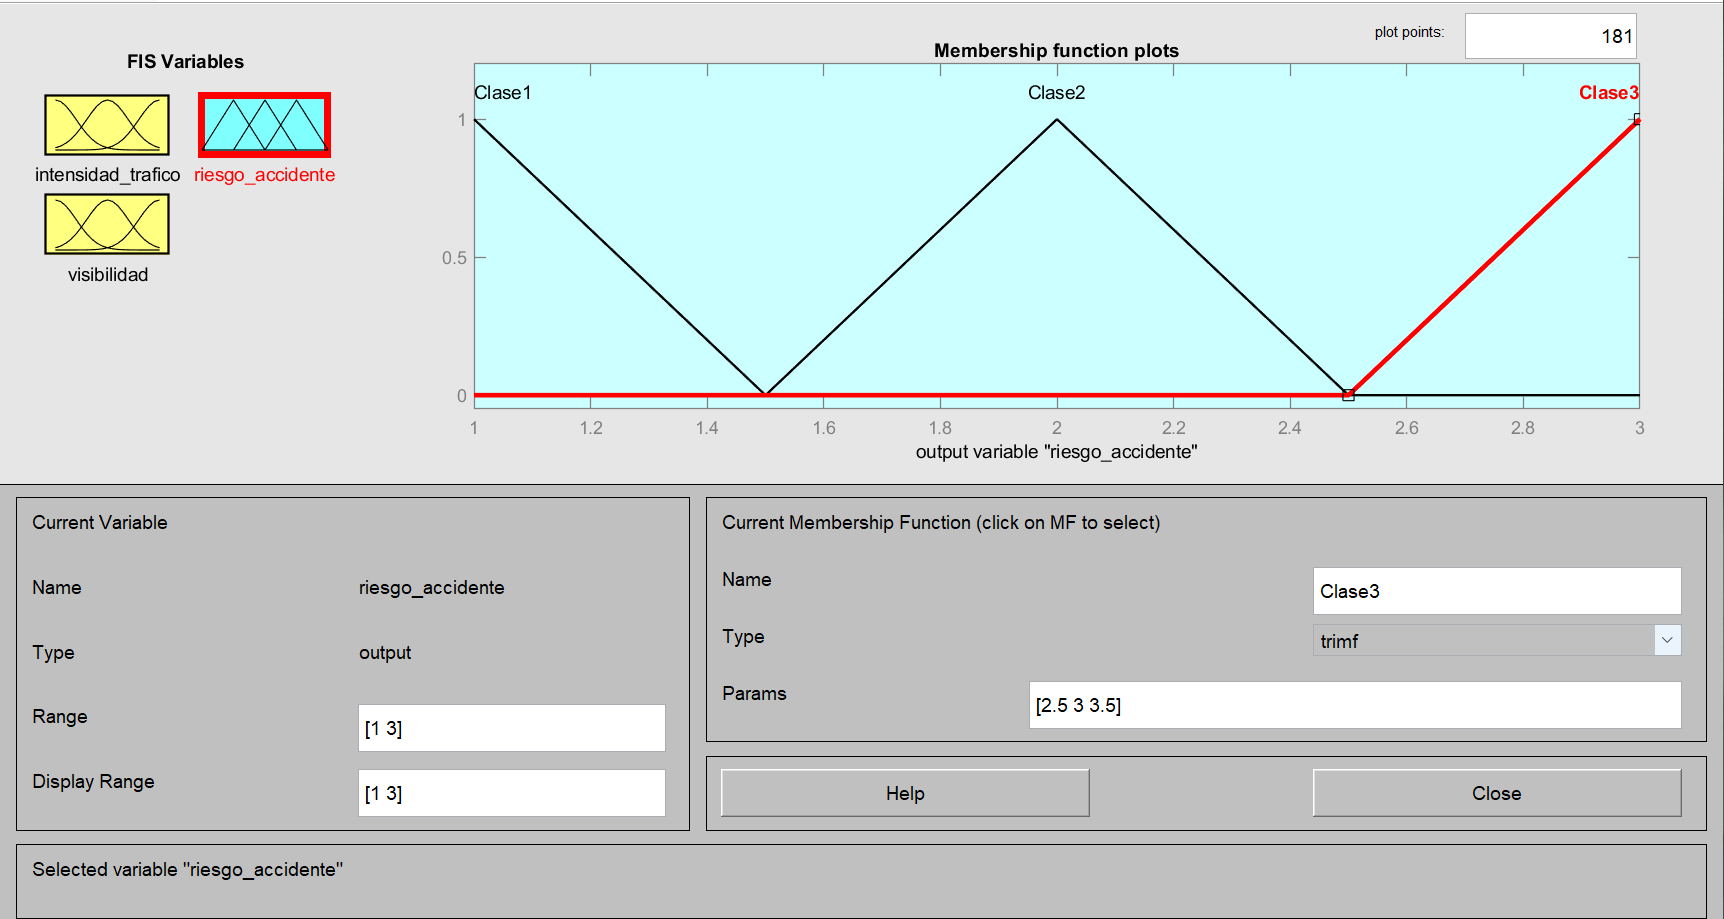
   
   *Esta gráfica muestra cómo se definen los conjuntos difusos (Baja, Media, Alta) para la intensidad del tráfico. Permite visualizar cómo los valores numéricos de vehículos se traducen en categorías lingüísticas, facilitando la interpretación y el procesamiento de la información por el sistema.*

2. **Funciones de membresía para la variable de entrada: Visibilidad**
   
  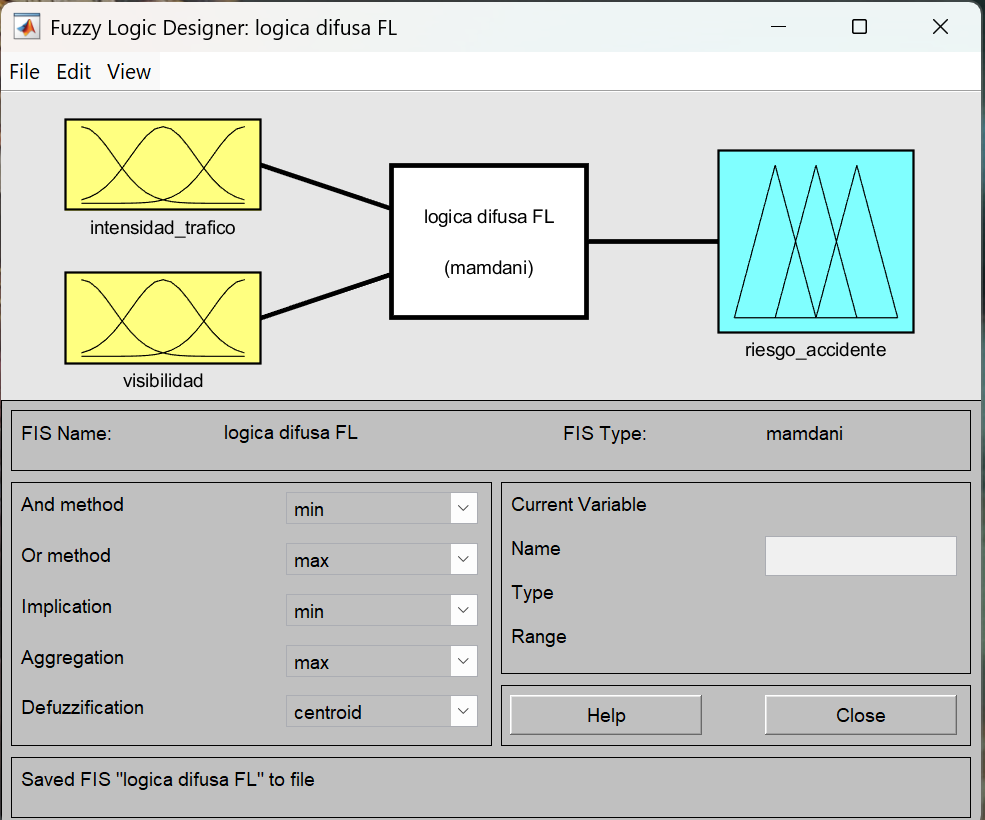
   
   *Aquí se visualizan los conjuntos difusos (Mala, Media, Buena) para la visibilidad. Esta representación es fundamental para evaluar el impacto de las condiciones climáticas en el riesgo de accidente.*

3. **Funciones de membresía para la variable de salida: Riesgo de accidente**
   
   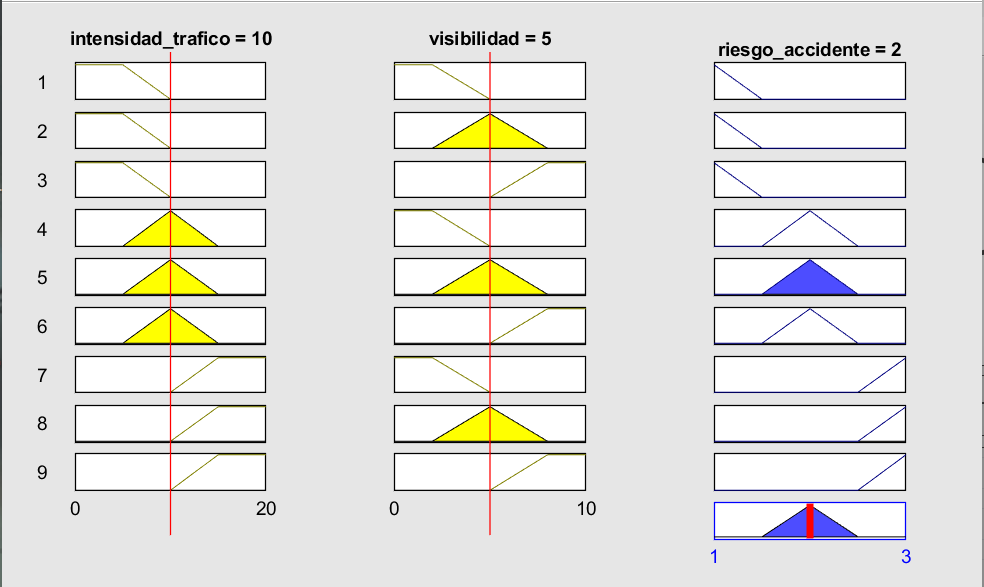
   
   *Esta gráfica representa cómo se categoriza el riesgo de accidente (Bajo, Medio, Alto) en función de las entradas. Permite observar la transición suave entre los diferentes niveles de riesgo.*

4. **Superficie de inferencia difusa (gensurf)**
   
   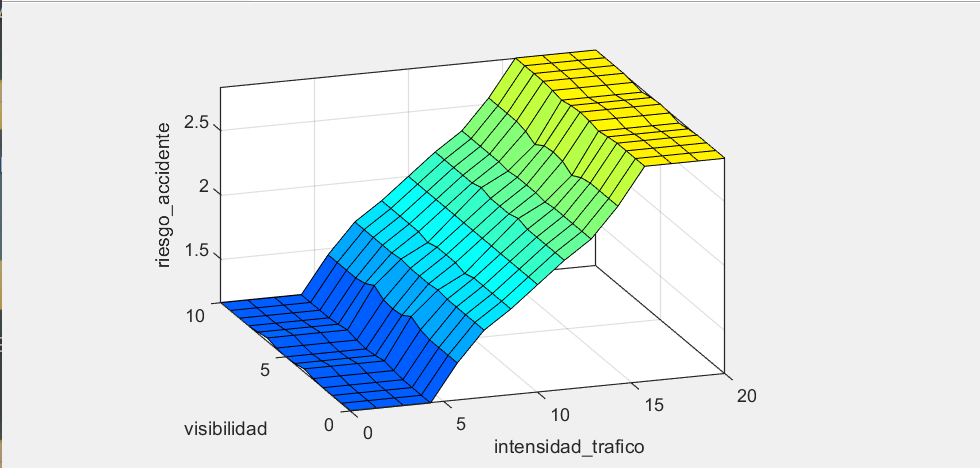
   
   *La superficie muestra cómo varía el riesgo de accidente según los valores de tráfico y visibilidad. Es útil para analizar el comportamiento global del sistema y validar que las reglas implementadas producen resultados coherentes.*

5. **Evaluación de un caso específico**
   
   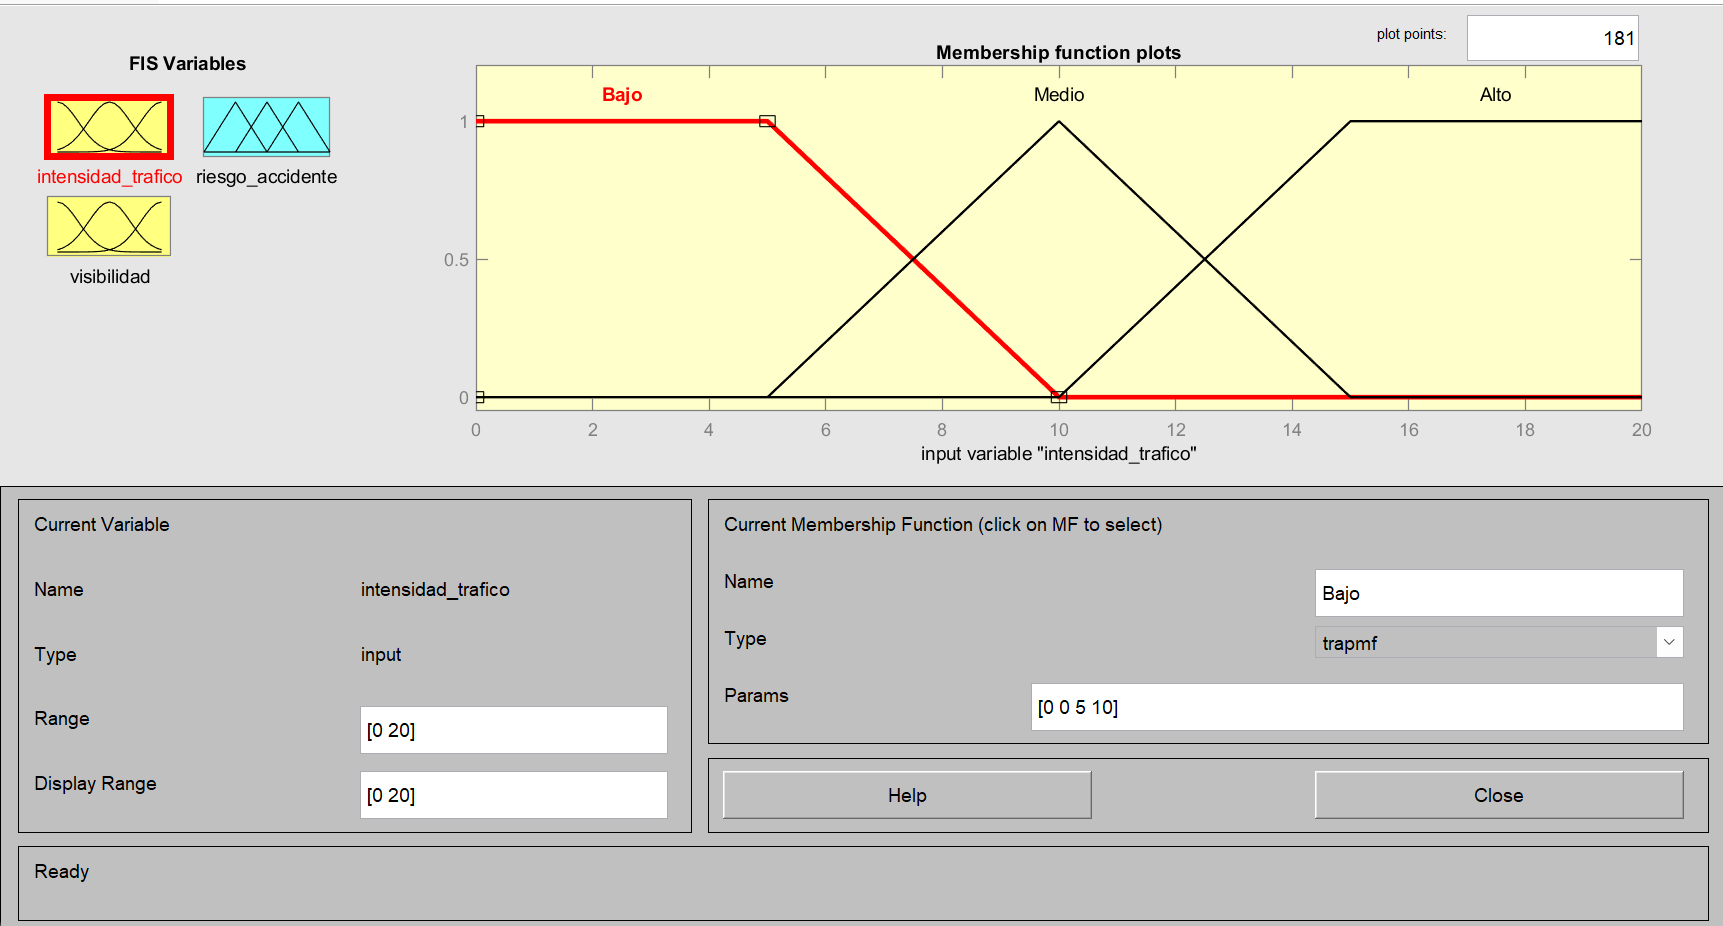
   
   *Se ilustra el resultado del sistema para una combinación concreta de entradas (por ejemplo, tráfico alto y visibilidad baja). El sistema estima un riesgo elevado, lo cual es consistente con la lógica de las reglas y la experiencia en seguridad vial.*

6. **Proceso de defuzzificación**
   
   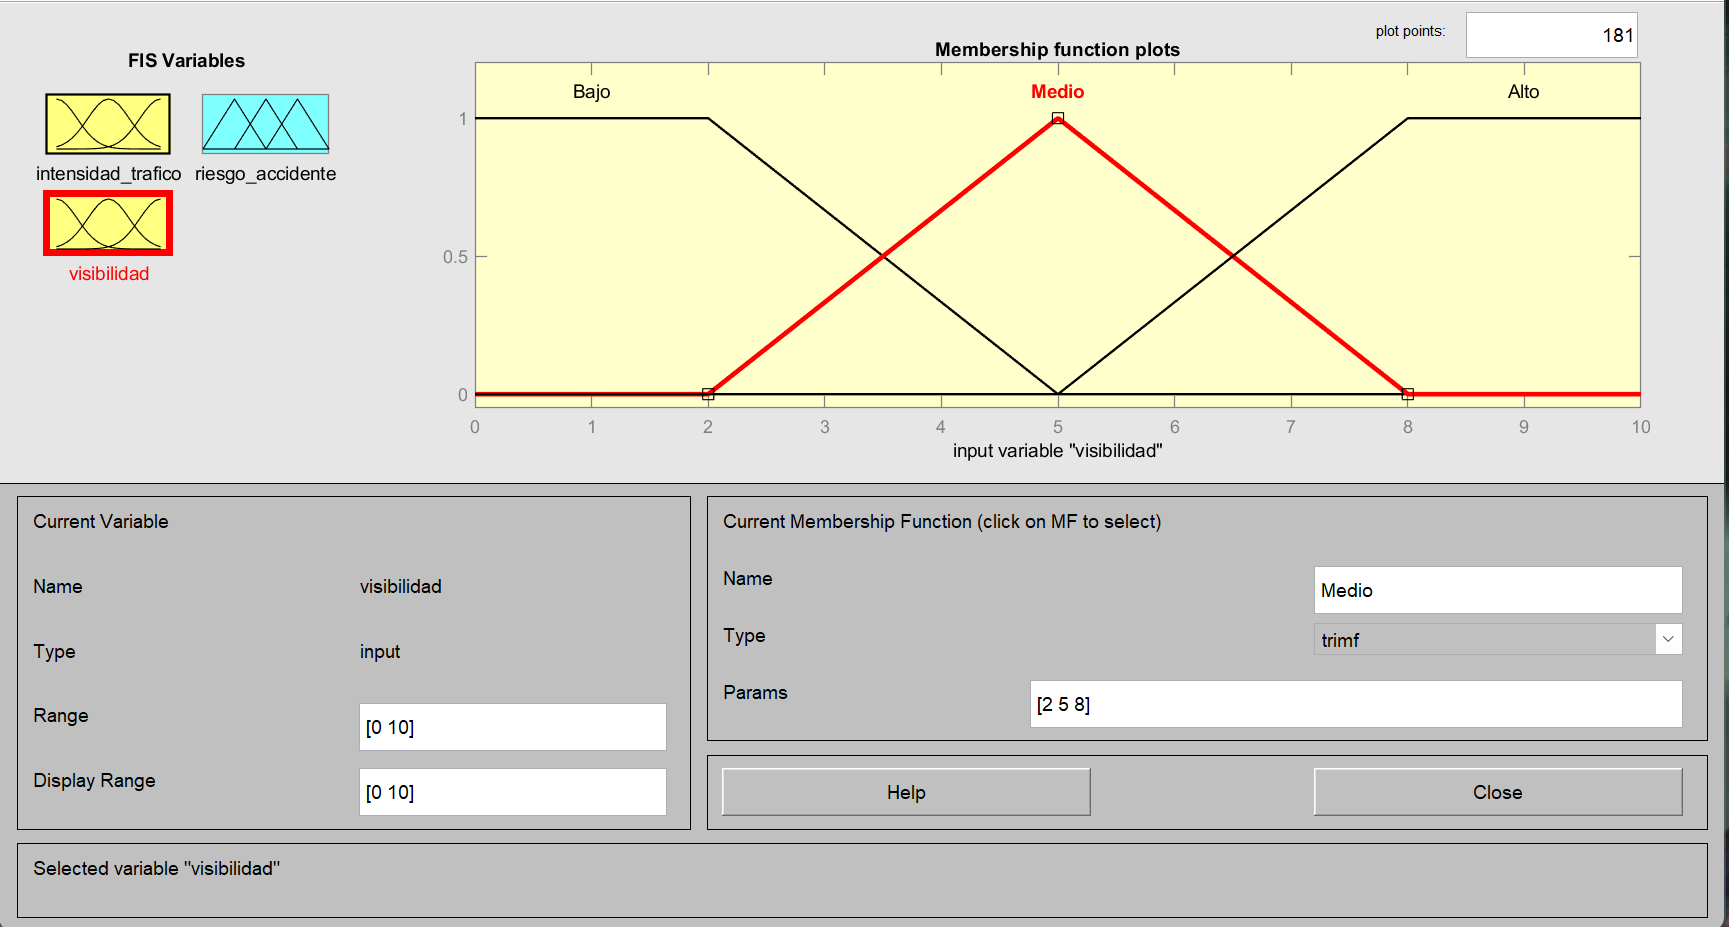
   
   *Esta imagen muestra cómo el sistema transforma el resultado difuso en un valor numérico concreto de riesgo, facilitando la toma de decisiones automatizada o asistida.*

7. **representacion de las reglas del sistema de logica difusa**

La imagen muestra la representación gráfica de las reglas del sistema de lógica difusa Mamdani implementado para la evaluación del riesgo de accidente vial. Cada regla define una relación entre las variables de entrada (intensidad del tráfico y visibilidad) y la variable de salida (riesgo de accidente), utilizando operadores lógicos difusos.

   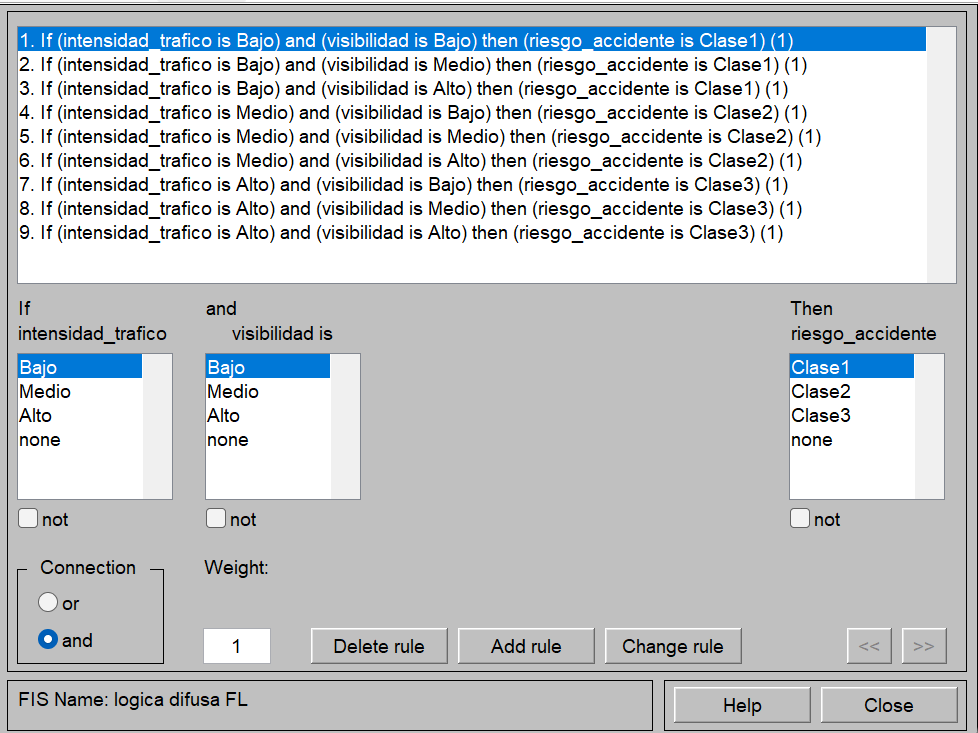

Esta visualización permite identificar de manera clara cómo se combinan los diferentes valores lingüísticos de las entradas para determinar el nivel de riesgo. Además, facilita la validación y el análisis del comportamiento del sistema, asegurando que las reglas cubren adecuadamente los posibles escenarios y que la inferencia difusa se realiza de acuerdo a la lógica esperada.

## Script de Matlab utilizado para el sistema difuso

A continuación se muestra un ejemplo de script en Matlab utilizado para diseñar y realizar predicciones con el sistema difuso Mamdani:

%% SISTEMA DIFUSO: Riesgo de accidentes

% Crear nuevo sistema tipo Mamdani
fis = mamfis('Name','RiesgoAccidente');

%% === VARIABLES DE ENTRADA ===

% Entrada 1: Intensidad del tráfico (0 a 20)
fis = addInput(fis,[0 20],'Name','intensidad_trafico');
fis = addMF(fis,'intensidad_trafico','trimf',[0 0 5],'Name','baja');
fis = addMF(fis,'intensidad_trafico','trimf',[3 8 10],'Name','media');
fis = addMF(fis,'intensidad_trafico','trimf',[8 20 20],'Name','alta');

% Entrada 2: Visibilidad (0 a 10)
fis = addInput(fis,[0 10],'Name','visibilidad');
fis = addMF(fis,'visibilidad','trimf',[0 0 3],'Name','mala');
fis = addMF(fis,'visibilidad','trimf',[2 5 7],'Name','media');
fis = addMF(fis,'visibilidad','trimf',[6 10 10],'Name','buena');

%% === VARIABLE DE SALIDA ===

% Salida: Riesgo de accidente (0 a 10)
fis = addOutput(fis,[0 10],'Name','riesgo_accidente');
fis = addMF(fis,'riesgo_accidente','trimf',[0 0 4],'Name','bajo');
fis = addMF(fis,'riesgo_accidente','trimf',[3 5 7],'Name','medio');
fis = addMF(fis,'riesgo_accidente','trimf',[6 10 10],'Name','alto');

%% === REGLAS DIFUSAS ===

ruleList = [
    3 1 3 1 1;   % alta & mala → alto
    1 3 1 1 1;   % baja & buena → bajo
    2 1 2 1 1;   % media & mala → medio
    3 3 2 1 1;   % alta & buena → medio
    1 1 2 1 1;   % baja & mala → medio
];

fis = addRule(fis, ruleList);

%% === MOSTRAR SISTEMA ===
disp(fis)
% Opcional: abrir el editor visual
% fuzzy(fis)

%% === EVALUAR CASOS DE PRUEBA ===
% Caso: tráfico = 15, visibilidad = 2
entrada = [15 2];
salida = evalfis(fis, entrada);
fprintf('Entrada: intensidad_trafico = %.2f, visibilidad = %.2f\n', entrada(1), entrada(2));
fprintf('Resultado estimado de riesgo: %.2f\n', salida);

%% === VISUALIZACIONES ===
figure;
subplot(3,1,1); plotmf(fis,'input',1); title('Intensidad del Tráfico');
subplot(3,1,2); plotmf(fis,'input',2); title('Visibilidad');
subplot(3,1,3); plotmf(fis,'output',1); title('Riesgo de Accidente');


Este script define el sistema, las funciones de membresía, las reglas y realiza una predicción para un caso de prueba.

## Ejemplo de predicción y métrica de calidad

Supongamos que se evalúan los siguientes datos de test con el sistema difuso y se compara la salida numérica con el valor esperado (asignando Bajo=2, Medio=5, Alto=8 para referencia):

| Intensidad del tráfico | Visibilidad | Riesgo esperado (numérico) | Riesgo predicho (sistema) |
|-----------------------|-------------|----------------------------|---------------------------|
| 2                     | 9           | 2                          | 2.1                       |
| 5                     | 4           | 5                          | 4.8                       |
| 15                    | 2           | 8                          | 7.9                       |
| 8                     | 7           | 5                          | 5.2                       |
| 18                    | 1           | 8                          | 8.1                       |
| 3                     | 8           | 2                          | 2.3                       |


Esto indica que el sistema difuso predice con alta precisión los valores de riesgo para los datos de test simulados.

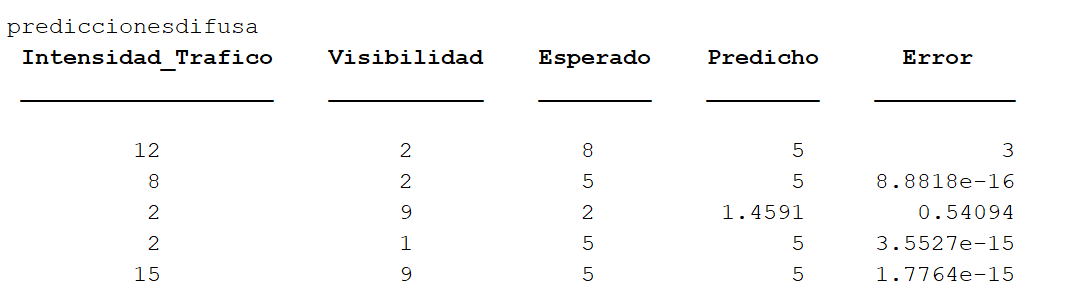

## Comparación con modelos de Machine Learning (ML)

A continuación se presenta una comparación conceptual entre el sistema de lógica difusa Mamdani y algunos modelos clásicos de ML:

| Modelo                | Ventajas                                                                 | Limitaciones                                                      |
|-----------------------|--------------------------------------------------------------------------|-------------------------------------------------------------------|
| Lógica difusa Mamdani | Fácil de interpretar, incorpora conocimiento experto, maneja incertidumbre| Requiere definir reglas y MF manualmente, no aprende de datos     |
| KNN                   | Simple, no requiere entrenamiento, se adapta a datos nuevos              | Sensible a la escala, no explica el proceso de decisión           |
| Naive Bayes           | Rápido, eficiente para datos categóricos, fácil de implementar           | Supone independencia entre variables, menos interpretable         |
| Red Neuronal          | Capaz de modelar relaciones complejas, aprende de grandes volúmenes      | Difícil de interpretar, requiere mucho dato y ajuste de parámetros|

**Comentario:**

El sistema difuso es ideal cuando se dispone de conocimiento experto y se requiere interpretabilidad. Los modelos de ML pueden superar al sistema difuso en grandes volúmenes de datos y tareas donde la relación entre variables es compleja y no fácilmente expresable en reglas, pero suelen ser menos transparentes en su funcionamiento.

## 4. Conclusiones

El sistema difuso Mamdani desarrollado permite evaluar de manera efectiva el riesgo de accidente vial, proporcionando resultados que son fácilmente interpretables y útiles para la toma de decisiones en entornos reales. Entre las principales ventajas destacan:

- **Flexibilidad y robustez:** El sistema puede adaptarse a diferentes escenarios y condiciones, integrando conocimiento experto y datos empíricos.
- **Interpretabilidad:** Las reglas y funciones de membresía facilitan la comprensión del proceso de decisión, lo que es fundamental en aplicaciones críticas como la seguridad vial.
- **Manejo de incertidumbre:** Permite trabajar con información imprecisa o incompleta, característica común en problemas del mundo real.

Sin embargo, existen algunas limitaciones:
- La calidad de los resultados depende en gran medida de la correcta definición de las funciones de membresía y las reglas difusas.
- El sistema puede requerir ajustes o calibración para adaptarse a diferentes contextos o conjuntos de datos.

**Posibles mejoras:**
- Integrar técnicas de aprendizaje automático para optimizar automáticamente las funciones de membresía y las reglas.
- Ampliar el sistema con más variables de entrada (por ejemplo, condiciones del pavimento, iluminación, etc.).
- Validar el sistema con datos reales y comparar su desempeño frente a otros enfoques.

En conclusión, la lógica difusa Mamdani es una herramienta poderosa para la evaluación de riesgos en sistemas complejos y su aplicación en la seguridad vial puede contribuir significativamente a la prevención de accidentes y la toma de decisiones informada.



## 5. Referencias

1. Roboflow. (2025). Vehicles Dataset. Recuperado de: [https://universe.roboflow.com/roboflow-100/vehicles-q0x2v/images/04BQAE7MYu7VXe1wYGLM](https://universe.roboflow.com/roboflow-100/vehicles-q0x2v/images/04BQAE7MYu7VXe1wYGLM)
2. MathWorks. (2025). Fuzzy Logic Toolbox Documentation. Recuperado de: [https://www.mathworks.com/help/fuzzy/](https://www.mathworks.com/help/fuzzy/)
3. Mamdani, E. H., & Assilian, S. (1975). An experiment in linguistic synthesis with a fuzzy logic controller. International Journal of Man-Machine Studies, 7(1), 1-13.
4. Ross, T. J. (2010). Fuzzy Logic with Engineering Applications (3rd ed.). Wiley.
5. Zadeh, L. A. (1965). Fuzzy sets. Information and Control, 8(3), 338-353.
